# 11 — Reverberant / Multipath Environments

**Goal**: quantify how room reverberation and specular reflections degrade
beamformer performance, and identify which algorithm is most robust.

Two physically distinct degradation mechanisms are studied:

1. **Diffuse reverberation** (late reverb, >50 ms) — modelled as an
   isotropic noise field: signals arriving from all directions with equal
   average power.  The CSM becomes
   `R = outer(h,h*) + (1/DRR)·R_diffuse + noise·I`
   where DRR (Direct-to-Reverberant Ratio) is the key parameter.

2. **Coherent specular reflection** (early reflection, <50 ms) — the
   source signal arrives via a second path from a different direction.
   At a single frequency the CSM has rank 1 with an *effective* steering
   vector `h_eff = h_direct + c·h_reflect`, causing a DoA bias.

Practical reference points for DRR:
- **>20 dB**: near-anechoic / outdoors — negligible reverb
- **10–15 dB**: typical office or lab at 1–2 m — moderate reverb
- **3–6 dB**: large reverberant room — significant degradation expected
- **<0 dB**: highly reverberant (T60 > 1 s) — reverb power exceeds direct


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
R_MIN  = 0.025
R_MAX  = 0.150
FREQ   = 4000.0
SNR_DB = 20.0
N_SNAP = 256


In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)
N_MICS = len(x_arr)
print(f'N_MICS = {N_MICS}')


N_MICS = 96


In [3]:
def sv(x, y, az_deg, freq):
    u = np.sin(np.radians(az_deg))
    return np.exp(1j * 2 * np.pi * freq / C * u * x) / np.sqrt(len(x))


def sm(x, y, az_grid, freq):
    u = np.sin(np.radians(az_grid))
    return np.exp(1j * 2 * np.pi * freq / C * np.outer(x, u)) / np.sqrt(len(x))


def make_R_diffuse(x, y, freq, n_pts=120, seed=0):
    """Isotropic noise CSM: average outer products over uniformly spaced azimuths."""
    az_pts = np.linspace(-90, 90, n_pts, endpoint=False)
    H = sm(x, y, az_pts, freq)   # (N, n_pts)
    return H @ H.conj().T / n_pts


def make_R_true(x, y, src_az, freq, snr_db, drr_db, R_diff):
    """Theoretical CSM: direct source + diffuse reverb + sensor noise."""
    N = len(x)
    h = sv(x, y, src_az, freq)
    noise_var = 1.0 / (10 ** (snr_db / 10))
    drr_lin   = 10 ** (drr_db / 10)
    return (np.outer(h, h.conj())
            + (1.0 / drr_lin) * R_diff
            + noise_var * np.eye(N))


def sample_csm(R_true, n_snap, seed=None):
    """Draw a finite-snapshot CSM from the true covariance via Cholesky sampling."""
    rng = np.random.default_rng(seed)
    N   = R_true.shape[0]
    reg = 1e-10 * np.trace(R_true) / N
    L   = np.linalg.cholesky(R_true + reg * np.eye(N))
    R_s = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        z     = rng.standard_normal(N) + 1j * rng.standard_normal(N)
        y_s   = L @ z / np.sqrt(2)
        R_s  += np.outer(y_s, y_s.conj())
    return R_s / n_snap


def beamform_ds(x, y, R, freq, az_grid):
    H = sm(x, y, az_grid, freq)
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_mvdr(x, y, R, freq, az_grid, diag_load=0.01):
    N = R.shape[0]
    Rl = R + diag_load * np.trace(R) / N * np.eye(N)
    Ri = inv(Rl)
    H  = sm(x, y, az_grid, freq)
    d  = np.real(np.sum(H.conj() * (Ri @ H), axis=0))
    return 1.0 / np.maximum(d, 1e-300)


def beamform_music(x, y, R, freq, az_grid, n_sources=1):
    _, ev = np.linalg.eigh(R)
    En    = ev[:, :R.shape[0] - n_sources]
    Ep    = En @ En.conj().T
    H     = sm(x, y, az_grid, freq)
    d     = np.real(np.sum(H.conj() * (Ep @ H), axis=0))
    return 1.0 / np.maximum(d, 1e-300)


def db_norm(x):
    return 10 * np.log10(np.maximum(x / x.max(), 1e-10))


az_grid  = np.linspace(-60, 60, 1201)
R_diff   = make_R_diffuse(x_arr, y_arr, FREQ)
DRR_VALS = [30, 20, 15, 10, 6, 3, 0, -3]
colors   = {'D&S': 'steelblue', 'MVDR': 'darkorange', 'MUSIC': 'forestgreen'}


## 1 — DoA Error vs DRR (Diffuse Reverberation, Single Source)

Source at az=25°, 4 kHz, 20 dB SNR, N_SNAP=256.
For each DRR, generate N_TRIALS independent CSMs (different noise seeds)
and measure peak DoA error.


In [4]:
AZ_TRUE  = 25.0
N_TRIALS = 20

results = {alg: {'mean': [], 'std': []} for alg in ['D&S', 'MVDR', 'MUSIC']}

for drr in DRR_VALS:
    errs = {'D&S': [], 'MVDR': [], 'MUSIC': []}
    R_t  = make_R_true(x_arr, y_arr, AZ_TRUE, FREQ, SNR_DB, drr, R_diff)
    for trial in range(N_TRIALS):
        R = sample_csm(R_t, N_SNAP, seed=trial * 1000 + int(drr * 10 + 100))
        for alg, fn, kw in [
            ('D&S',   beamform_ds,    {}),
            ('MVDR',  beamform_mvdr,  {}),
            ('MUSIC', beamform_music, {'n_sources': 1}),
        ]:
            m   = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
            errs[alg].append(abs(az_grid[np.argmax(m)] - AZ_TRUE))
    for alg in results:
        results[alg]['mean'].append(np.mean(errs[alg]))
        results[alg]['std'].append(np.std(errs[alg]))

print('DRR sweep complete')
for alg in ['D&S', 'MVDR', 'MUSIC']:
    for drr, m, s in zip(DRR_VALS, results[alg]['mean'], results[alg]['std']):
        print(f'  {alg}  DRR={drr:4d} dB  err={m:.3f}° ± {s:.3f}°')


DRR sweep complete
  D&S  DRR=  30 dB  err=0.045° ± 0.050°
  D&S  DRR=  20 dB  err=0.045° ± 0.059°
  D&S  DRR=  15 dB  err=0.035° ± 0.048°
  D&S  DRR=  10 dB  err=0.035° ± 0.048°
  D&S  DRR=   6 dB  err=0.065° ± 0.079°
  D&S  DRR=   3 dB  err=0.150° ± 0.097°
  D&S  DRR=   0 dB  err=0.180° ± 0.103°
  D&S  DRR=  -3 dB  err=0.260° ± 0.208°
  MVDR  DRR=  30 dB  err=0.045° ± 0.059°
  MVDR  DRR=  20 dB  err=0.040° ± 0.049°
  MVDR  DRR=  15 dB  err=0.050° ± 0.050°
  MVDR  DRR=  10 dB  err=0.045° ± 0.050°
  MVDR  DRR=   6 dB  err=0.070° ± 0.064°
  MVDR  DRR=   3 dB  err=0.140° ± 0.111°
  MVDR  DRR=   0 dB  err=0.140° ± 0.120°
  MVDR  DRR=  -3 dB  err=0.200° ± 0.167°
  MUSIC  DRR=  30 dB  err=0.045° ± 0.050°
  MUSIC  DRR=  20 dB  err=0.045° ± 0.059°
  MUSIC  DRR=  15 dB  err=0.035° ± 0.048°
  MUSIC  DRR=  10 dB  err=0.035° ± 0.048°
  MUSIC  DRR=   6 dB  err=0.065° ± 0.079°
  MUSIC  DRR=   3 dB  err=0.150° ± 0.097°
  MUSIC  DRR=   0 dB  err=0.200° ± 0.118°
  MUSIC  DRR=  -3 dB  err=0.290° ± 0.23

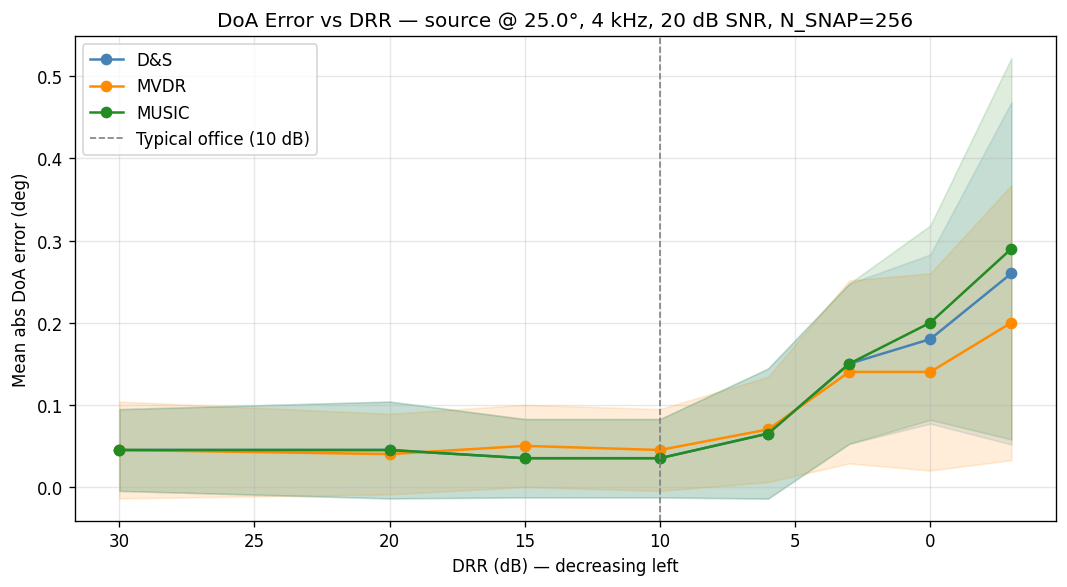

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for alg in ['D&S', 'MVDR', 'MUSIC']:
    mean = np.array(results[alg]['mean'])
    std  = np.array(results[alg]['std'])
    ax.plot(DRR_VALS, mean, 'o-', color=colors[alg], label=alg, linewidth=1.5)
    ax.fill_between(DRR_VALS, mean - std, mean + std,
                    color=colors[alg], alpha=0.15)
ax.invert_xaxis()
ax.axvline(10, color='gray', linestyle='--', linewidth=1, label='Typical office (10 dB)')
ax.set_xlabel('DRR (dB) — decreasing left')
ax.set_ylabel('Mean abs DoA error (deg)')
ax.set_title(f'DoA Error vs DRR — source @ {AZ_TRUE}°, {FREQ/1000:.0f} kHz, '
             f'{SNR_DB:.0f} dB SNR, N_SNAP={N_SNAP}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reverb_doa_vs_drr.png', dpi=150, bbox_inches='tight')
plt.show()


## 2 — Spectrum at Different DRRs

Show the beamformer spectrum for each algorithm at four DRR levels.
A clean single-peak spectrum is the goal; sidelobe rise and peak shift
indicate reverb degradation.


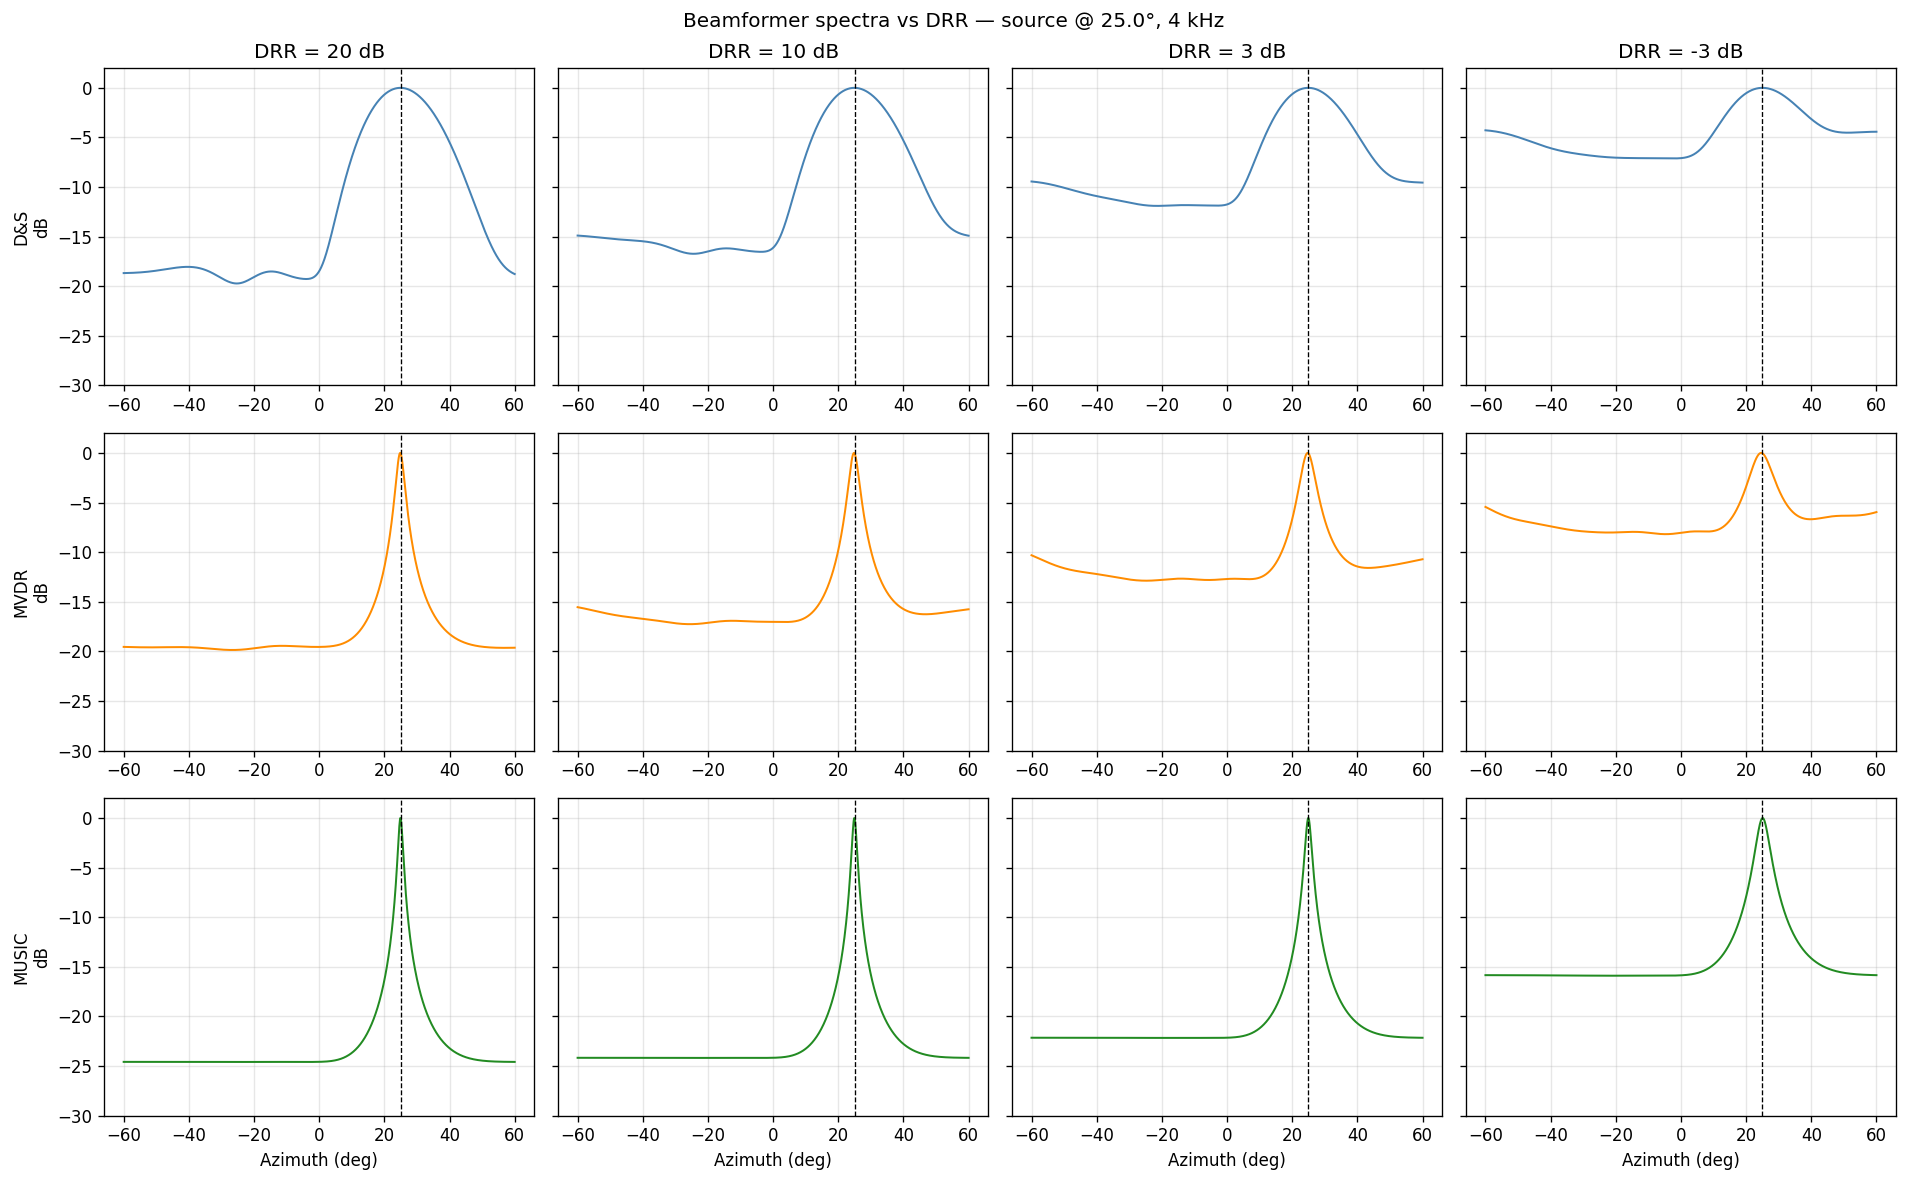

In [6]:
drr_show = [20, 10, 3, -3]
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey='row')

for col, drr in enumerate(drr_show):
    R_t = make_R_true(x_arr, y_arr, AZ_TRUE, FREQ, SNR_DB, drr, R_diff)
    R   = sample_csm(R_t, N_SNAP, seed=42)
    for row, (alg, fn, kw) in enumerate([
        ('D&S',   beamform_ds,    {}),
        ('MVDR',  beamform_mvdr,  {}),
        ('MUSIC', beamform_music, {'n_sources': 1}),
    ]):
        ax = axes[row, col]
        m  = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
        ax.plot(az_grid, db_norm(m), color=colors[alg], linewidth=1.2)
        ax.axvline(AZ_TRUE, color='k', linestyle='--', linewidth=0.8)
        ax.set_ylim(-30, 2)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(f'DRR = {drr} dB')
        if col == 0:
            ax.set_ylabel(f'{alg}\ndB')
        if row == 2:
            ax.set_xlabel('Azimuth (deg)')

plt.suptitle(f'Beamformer spectra vs DRR — source @ {AZ_TRUE}°, {FREQ/1000:.0f} kHz')
plt.tight_layout()
plt.savefig('reverb_spectra.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 — Resolution Reliability vs DRR

Two sources at ±15°, 4 kHz, 20 dB SNR, N_SNAP=256.
Resolution criterion: −6 dB valley between the two peaks.


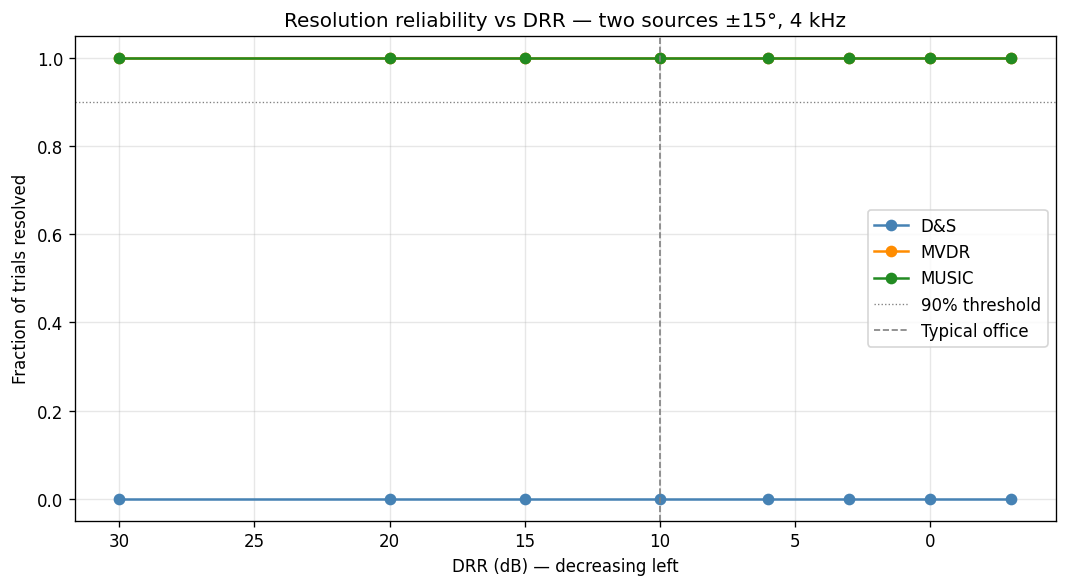

In [7]:
N_TRIALS_R = 20


def is_resolved(az_grid, m, az1=-15.0, az2=15.0, thr=-6):
    i1, i2 = np.argmin(np.abs(az_grid - az1)), np.argmin(np.abs(az_grid - az2))
    lo, hi = min(i1, i2), max(i1, i2)
    valley = m[lo:hi+1].min()
    return 10 * np.log10(valley / m.max()) < thr


src_two  = [(az, 1.0) for az in [-15.0, 15.0]]

res_rate = {alg: [] for alg in ['D&S', 'MVDR', 'MUSIC']}
R_diff2  = make_R_diffuse(x_arr, y_arr, FREQ)

for drr in DRR_VALS:
    h1  = sv(x_arr, y_arr, -15.0, FREQ)
    h2  = sv(x_arr, y_arr,  15.0, FREQ)
    drr_lin   = 10 ** (drr / 10)
    noise_var = 1.0 / (10 ** (SNR_DB / 10))
    R_t = (np.outer(h1, h1.conj()) + np.outer(h2, h2.conj())
           + (1.0 / drr_lin) * R_diff2
           + noise_var * np.eye(N_MICS))
    for alg in res_rate:
        resolved = 0
        for trial in range(N_TRIALS_R):
            R = sample_csm(R_t, N_SNAP, seed=trial * 500 + int(drr * 10 + 200))
            if alg == 'D&S':
                m = beamform_ds(x_arr, y_arr, R, FREQ, az_grid)
            elif alg == 'MVDR':
                m = beamform_mvdr(x_arr, y_arr, R, FREQ, az_grid)
            else:
                m = beamform_music(x_arr, y_arr, R, FREQ, az_grid, n_sources=2)
            if is_resolved(az_grid, m):
                resolved += 1
        res_rate[alg].append(resolved / N_TRIALS_R)

fig, ax = plt.subplots(figsize=(9, 5))
for alg in ['D&S', 'MVDR', 'MUSIC']:
    ax.plot(DRR_VALS, res_rate[alg], 'o-', color=colors[alg], label=alg, linewidth=1.5)
ax.invert_xaxis()
ax.axhline(0.9, color='gray', linestyle=':', linewidth=0.8, label='90% threshold')
ax.axvline(10, color='gray', linestyle='--', linewidth=1, label='Typical office')
ax.set_xlabel('DRR (dB) — decreasing left')
ax.set_ylabel('Fraction of trials resolved')
ax.set_title(f'Resolution reliability vs DRR — two sources ±15°, {FREQ/1000:.0f} kHz')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reverb_resolution.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 — Coherent Specular Reflection: Ghost Peaks

A single strong early reflection from az=−35° (wall behind the source plane).
Three reflection amplitudes tested: 0.3, 0.5, 0.7 (−10.5, −6, −3 dB).
Unlike diffuse reverberation, a specular reflection at a fixed direction
acts as a coherent second source at a wrong location, creating a ghost peak.


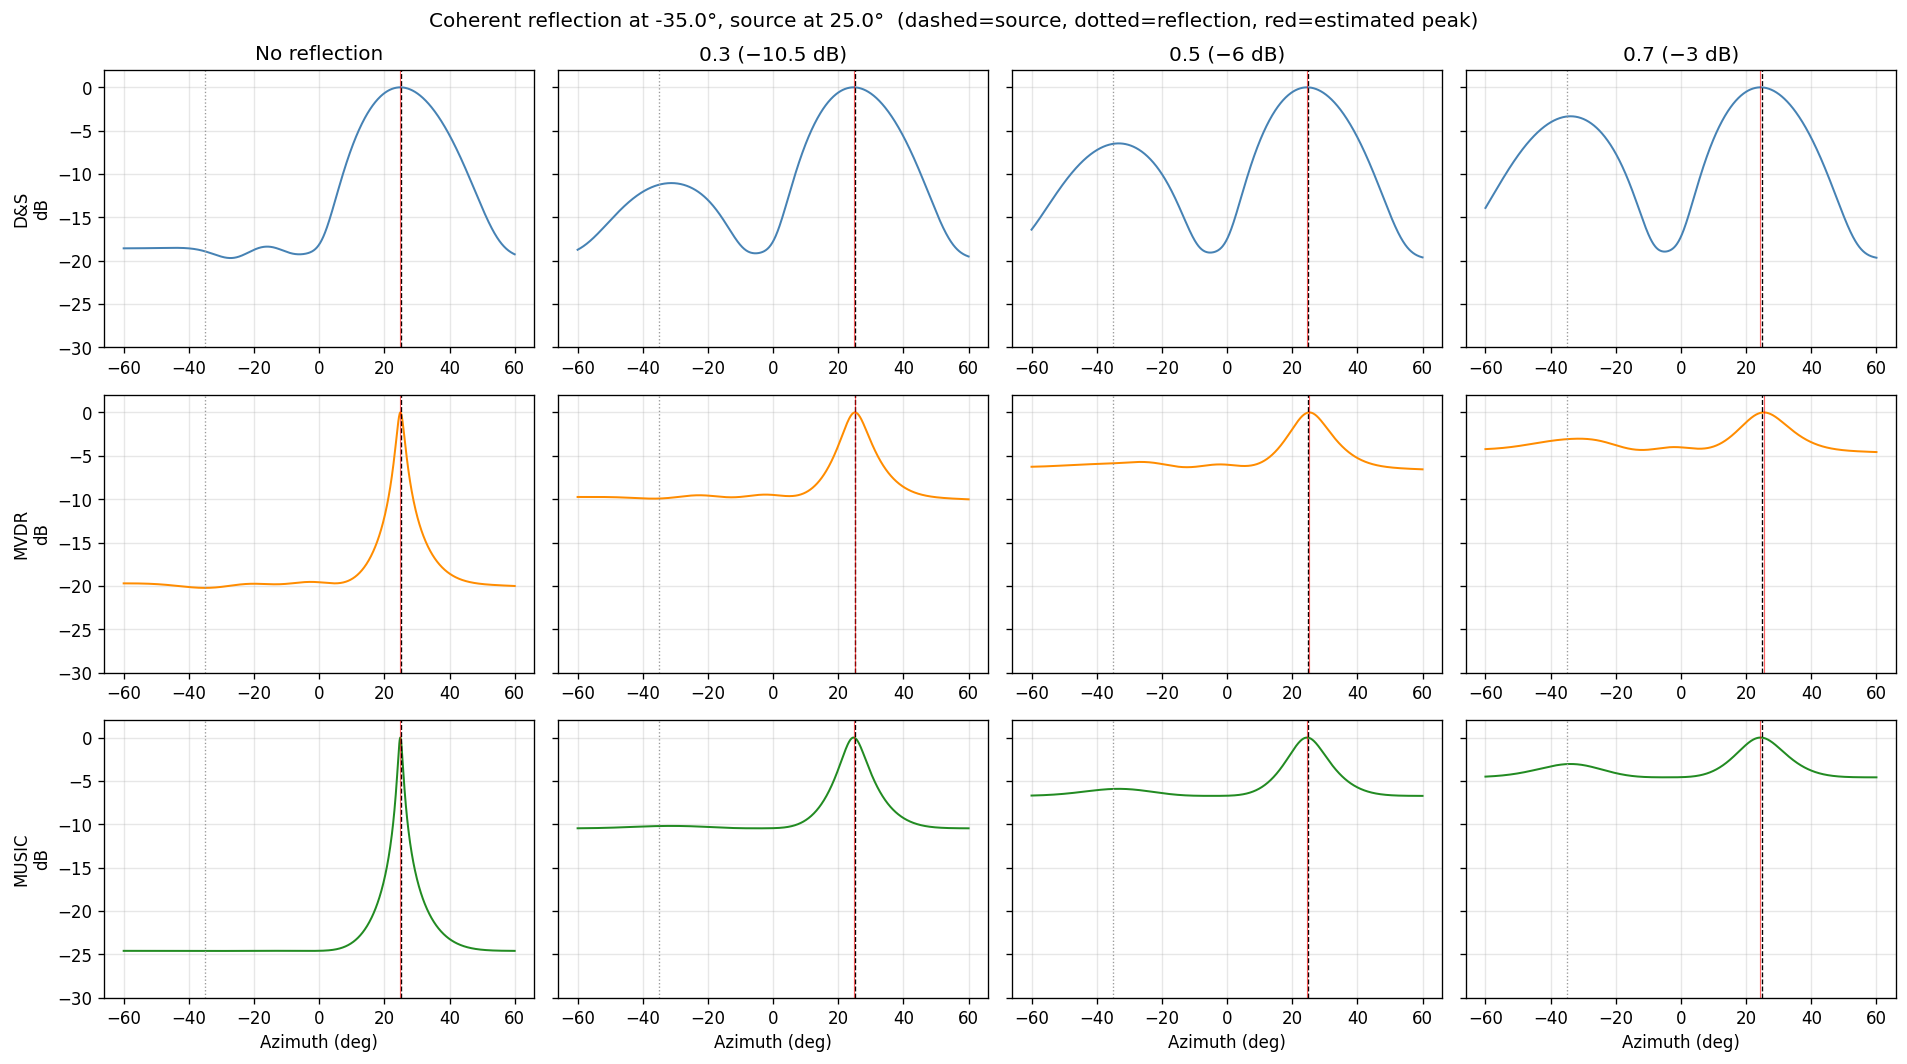

Peak az estimate vs reflection amplitude (true source @ 25.0°):
  No reflection              D&S=+25.0°  MVDR=+25.0°  MUSIC=+25.0°


  0.3 (−10.5 dB)             D&S=+24.8°  MVDR=+24.9°  MUSIC=+24.8°


  0.5 (−6 dB)                D&S=+24.7°  MVDR=+24.9°  MUSIC=+24.7°


  0.7 (−3 dB)                D&S=+24.5°  MVDR=+24.8°  MUSIC=+24.5°


In [8]:
REFLECT_AZ  = -35.0
AMP_VALS    = [0.0, 0.3, 0.5, 0.7]   # 0 = no reflection
AMP_LABELS  = ['No reflection', '0.3 (−10.5 dB)', '0.5 (−6 dB)', '0.7 (−3 dB)']

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharey='row')

for col, (amp, lbl) in enumerate(zip(AMP_VALS, AMP_LABELS)):
    # Coherent reflection: effective steering vector h_eff = h_direct + amp*h_reflect
    h_d   = sv(x_arr, y_arr, AZ_TRUE, FREQ)
    h_r   = sv(x_arr, y_arr, REFLECT_AZ, FREQ)
    # Random phase per snapshot makes it properly coherent at this freq
    h_eff = h_d + amp * h_r
    noise_var = 1.0 / (10 ** (SNR_DB / 10))
    R_t = np.outer(h_eff, h_eff.conj()) + noise_var * np.eye(N_MICS)
    R   = sample_csm(R_t, N_SNAP, seed=99)

    for row, (alg, fn, kw) in enumerate([
        ('D&S',   beamform_ds,    {}),
        ('MVDR',  beamform_mvdr,  {}),
        ('MUSIC', beamform_music, {'n_sources': 1}),
    ]):
        ax = axes[row, col]
        m  = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
        ax.plot(az_grid, db_norm(m), color=colors[alg], linewidth=1.2)
        ax.axvline(AZ_TRUE,      color='k',   linestyle='--', linewidth=0.8)
        ax.axvline(REFLECT_AZ,   color='0.6', linestyle=':',  linewidth=0.8)
        ax.set_ylim(-30, 2)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(lbl)
        if col == 0:
            ax.set_ylabel(f'{alg}\ndB')
        if row == 2:
            ax.set_xlabel('Azimuth (deg)')
        # mark estimated peak
        az_est = az_grid[np.argmax(m)]
        ax.axvline(az_est, color='r', linestyle='-', linewidth=0.7, alpha=0.6)

plt.suptitle(f'Coherent reflection at {REFLECT_AZ}°, source at {AZ_TRUE}°  '
             f'(dashed=source, dotted=reflection, red=estimated peak)')
plt.tight_layout()
plt.savefig('reverb_coherent_ghost.png', dpi=150, bbox_inches='tight')
plt.show()

# Report peak shifts
print(f'Peak az estimate vs reflection amplitude (true source @ {AZ_TRUE}°):')
for amp, lbl in zip(AMP_VALS, AMP_LABELS):
    h_eff = sv(x_arr, y_arr, AZ_TRUE, FREQ) + amp * sv(x_arr, y_arr, REFLECT_AZ, FREQ)
    R_t   = np.outer(h_eff, h_eff.conj()) + 1e-4 * np.eye(N_MICS)
    R     = sample_csm(R_t, N_SNAP, seed=99)
    row_out = [lbl]
    for alg, fn, kw in [
        ('D&S',   beamform_ds,    {}),
        ('MVDR',  beamform_mvdr,  {}),
        ('MUSIC', beamform_music, {'n_sources': 1}),
    ]:
        m = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
        row_out.append(f'{az_grid[np.argmax(m)]:+.1f}°')
    print(f'  {lbl:25s}  D&S={row_out[1]}  MVDR={row_out[2]}  MUSIC={row_out[3]}')


## Summary


In [9]:
print('=== DoA error at key DRR values (single source @ 25°) ===')
hdr = f'  {"DRR":>8}  {"D&S":>10}  {"MVDR":>10}  {"MUSIC":>10}'
print(hdr)
for i, drr in enumerate(DRR_VALS):
    row = f'  {drr:>5d} dB'
    for alg in ['D&S', 'MVDR', 'MUSIC']:
        row += f'  {results[alg]["mean"][i]:8.3f}°'
    print(row)
print()
print('=== Resolution reliability at key DRR values (±15° sources) ===')
print(hdr.replace('°', ''))
for i, drr in enumerate(DRR_VALS):
    row = f'  {drr:>5d} dB'
    for alg in ['D&S', 'MVDR', 'MUSIC']:
        row += f'  {res_rate[alg][i]:>10.2f}'
    print(row)


=== DoA error at key DRR values (single source @ 25°) ===
       DRR         D&S        MVDR       MUSIC
     30 dB     0.045°     0.045°     0.045°
     20 dB     0.045°     0.040°     0.045°
     15 dB     0.035°     0.050°     0.035°
     10 dB     0.035°     0.045°     0.035°
      6 dB     0.065°     0.070°     0.065°
      3 dB     0.150°     0.140°     0.150°
      0 dB     0.180°     0.140°     0.200°
     -3 dB     0.260°     0.200°     0.290°

=== Resolution reliability at key DRR values (±15° sources) ===
       DRR         D&S        MVDR       MUSIC
     30 dB        0.00        1.00        1.00
     20 dB        0.00        1.00        1.00
     15 dB        0.00        1.00        1.00
     10 dB        0.00        1.00        1.00
      6 dB        0.00        1.00        1.00
      3 dB        0.00        1.00        1.00
      0 dB        0.00        1.00        1.00
     -3 dB        0.00        1.00        1.00
